# MLP Adam

### Importamos librerias necesarias

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

### Concepto 1: Función de pérdida
`Binary Cross-Entropy` 

In [134]:
def binary_cross_entropy(y_true, y_pred, epsilon = 1e-8):
    """
    y_true: array (m,) o (m, 1) de etiquetas 0/1
    y_pred: array (m, 1) de probabilidades predichas
    """
    y_true = y_true.reshape(-1, 1)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # evitar log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

### Concepto 2: Funciones de activación

In [135]:
# Usada en el forward pass
def relu(Z):
    return np.maximum(0, Z)

# Necesaria para el backward pass
def relu_derivative(Z):
    # Derivada de ReLU: 1 si Z > 0, 0 en caso contrario
    return (Z > 0).astype(Z.dtype)


def sigmoid(Z):
    # Clipping para evitar overflow en np.exp con valores extremos
    Z = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z))

### Concepto 3: Momento estadísticos
`Inicialización He:` Se usa la inicialización He ya que estamos usando ReLu como función de activación. 

In [136]:
def he_init(n_in, n_out, rng):
    """Pesos ~ Normal(0, sqrt(2/n_in)), forma (n_in, n_out)."""
    return rng.standard_normal((n_in, n_out)) * np.sqrt(2.0 / n_in)

### Concepto 4 y 5: Perceptron Multicapa (MLP) con Adam como optimizador

In [137]:
class MLP:
    """
    MLP totalmente conectado para clasificacion binaria.

    layer_sizes : lista de enteros, p.ej. [n_features, 64, 32, 1]
    seed        : semilla para reproducibilidad de la inicializacion
    """

    def __init__(self, layer_sizes, seed = 42):
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1
        rng = np.random.default_rng(seed)

        # Pesos y biases por capa
        self.W = []  # cada W[i] tiene forma (n_in, n_out)
        self.b = []  # cada b[i] tiene forma (1, n_out) para broadcasting
        for i in range(self.n_layers):
            n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(he_init(n_in, n_out, rng))
            self.b.append(np.zeros((1, n_out)))

        # Estado de Adam: primer y segundo momento por parametro
        self._init_adam_state()

    def _init_adam_state(self):
        self.mW = [np.zeros_like(W) for W in self.W]
        self.vW = [np.zeros_like(W) for W in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]
        self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0  # contador de pasos de Adam (para bias correction)

    # ------------------------------------------------------------------
    # FORWARD PASS
    # ------------------------------------------------------------------
    def forward(self, X):
        """
        X: array (m, n_features).
        Cachea activaciones y pre-activaciones para el backward pass.
        """
        activations = [X]   # activacion en cada capa (incluyendo entrada)
        zs = []             # pre-activaciones (antes de la no-linealidad)

        current_activation = X
        for i in range(self.n_layers):
            # Usamos Z por nomenclatura usada en texto académicos y consistencia con la manera en la cual definimos las funciones de activación
            Z = current_activation @ self.W[i] + self.b[i]   # broadcasting suma el bias a cada fila
            zs.append(Z)

            if i < self.n_layers - 1:
                current_activation = relu(Z)         # capas ocultas
            else:
                current_activation = sigmoid(Z)      # capa de salida (clasificacion binaria)

            activations.append(current_activation)

        self._cache = {"activations": activations, "zs": zs}
        return current_activation

    # ------------------------------------------------------------------
    # BACKWARD PASS (gradientes manuales con regla de la cadena)
    # ------------------------------------------------------------------
    def backward(self, y_true):
        """
        y_true: array (m,) o (m, 1) de etiquetas 0/1.
        Devuelve listas de gradientes para W y b.
        """
        activations = self._cache["activations"]
        zs = self._cache["zs"]
        m = y_true.shape[0]
        y_true = y_true.reshape(-1, 1)

        grads_W = [None] * self.n_layers
        grads_b = [None] * self.n_layers

        # Truco: la derivada combinada de BCE + sigmoid se simplifica a
        # dL/dZ = (y_pred - y_true) / m. Numericamente estable y eficiente.
        y_pred = activations[-1]
        dZ = (y_pred - y_true) / m   # shape (m, 1)

        # Retropropagar capa por capa, de la ultima a la primera
        for layer in reversed(range(self.n_layers)):
            previous_activation = activations[layer]

            grads_W[layer] = previous_activation.T @ dZ                    # dL/dW
            grads_b[layer] = np.sum(dZ, axis = 0, keepdims = True)  # dL/db

            if layer > 0:
                dA_prev = dZ @ self.W[layer].T
                dZ = dA_prev * relu_derivative(zs[layer - 1])

        return grads_W, grads_b

    # ------------------------------------------------------------------
    # OPTIMIZADOR ADAM (implementado a mano, sin usar APIs de entrenamiento de Keras/Pytorch ni nada)
    # ------------------------------------------------------------------
    def adam_step(self, grads_W, grads_b,
                  lr = 0.001, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8):
        """
        Un paso de Adam:
            m_t = beta1 * m_{t-1} + (1-beta1) * g
            v_t = beta2 * v_{t-1} + (1-beta2) * g^2
            m_hat = m_t / (1 - beta1^t)        # bias correction
            v_hat = v_t / (1 - beta2^t)
            param -= lr * m_hat / (sqrt(v_hat) + epsilon)

        Con NumPy todas las operaciones son vectorizadas: no necesitamos
        loops sobre los elementos de las matrices.
        """
        self.t += 1
        bc1 = 1 - beta1 ** self.t
        bc2 = 1 - beta2 ** self.t

        for layer in range(self.n_layers):
            # --- Pesos ---
            gW = grads_W[layer]
            self.mW[layer] = beta1 * self.mW[layer] + (1 - beta1) * gW
            self.vW[layer] = beta2 * self.vW[layer] + (1 - beta2) * (gW ** 2)
            m_hat = self.mW[layer] / bc1
            v_hat = self.vW[layer] / bc2
            self.W[layer] -= lr * m_hat / (np.sqrt(v_hat) + epsilon)

            # --- Biases ---
            gb = grads_b[layer]
            self.mb[layer] = beta1 * self.mb[layer] + (1 - beta1) * gb
            self.vb[layer] = beta2 * self.vb[layer] + (1 - beta2) * (gb ** 2)
            m_hat_b = self.mb[layer] / bc1
            v_hat_b = self.vb[layer] / bc2
            self.b[layer] -= lr * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

    # ------------------------------------------------------------------
    # ENTRENAMIENTO
    # ------------------------------------------------------------------
    def fit(self, X, y, epochs = 100, batch_size = 32, lr = 0.001,
            verbose = True, seed = 0):
        rng = np.random.default_rng(seed)
        n_samples = X.shape[0]
        history = []

        for epoch in range(1, epochs + 1):
            # Mezclar el dataset cada epoca
            perm = rng.permutation(n_samples)
            X_shuf, y_shuf = X[perm], y[perm]

            epoch_losses = []
            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuf[start:end]
                y_batch = y_shuf[start:end]

                y_pred = self.forward(X_batch)
                loss = binary_cross_entropy(y_batch, y_pred)
                epoch_losses.append(loss)

                grads_W, grads_b = self.backward(y_batch)
                self.adam_step(grads_W, grads_b, lr = lr)

            avg_loss = float(np.mean(epoch_losses))
            history.append(avg_loss)

            if verbose and (epoch == 1 or epoch % max(1, epochs // 10) == 0):
                acc = self.accuracy(X, y)
                print(f"Epoch {epoch:4d}/{epochs} - loss: {avg_loss:.4f} "
                      f"- train_acc: {acc:.4f}")

        return history

    # ------------------------------------------------------------------
    # INFERENCIA
    # ------------------------------------------------------------------
    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold = 0.5):
        return (self.forward(X).ravel() >= threshold).astype(int)

    def accuracy(self, X, y):
        return float(np.mean(self.predict(X) == y))

### Ejecución

### Cargamos el dataset

In [138]:
# Carga del dataset (separador pipe)
df = pd.read_csv('new_dataset.csv', sep='|', parse_dates=['Submit'])
df.head()

,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqMem,ReqNodes,ResvCPURAW,Submit,TimelimitRaw,Partition,Priority,QOS,State
0,3800474.0,4147584,1,100Mc,1,345743,2024-06-25 14:03:31,1440,nukwa-wide,7046,normal,TIMEOUT
1,0.0,4147968,1,100Mc,1,172857,2024-06-25 14:03:34,1440,nukwa-wide,7046,normal,TIMEOUT
2,3774906.0,4147392,1,100Mc,1,432175,2024-06-25 14:03:37,1440,nukwa-wide,7046,normal,TIMEOUT
3,3782559.0,4147536,1,100Mc,1,259290,2024-06-25 14:03:47,1440,nukwa-wide,7046,normal,TIMEOUT
4,3723128.0,4088688,1,100Mc,1,518590,2024-06-25 14:03:56,1440,nukwa-wide,7046,normal,COMPLETED


### Replicamos EDA de proyecto anterior

### Valores nulos y duplicados

In [139]:
nulls = df.isnull().sum()
nulls_pct = nulls / len(df) * 100
null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct}).query('Nulos > 0')

if null_df.empty:
    print("No hay valores nulos en el dataset.")
else:
    display(null_df)

dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {dups} ({dups/len(df)*100:.2f}%)")

,Nulos,% Nulos
ConsumedEnergyRaw,12394,5.401236



Filas duplicadas: 11258 (4.91%)


### Variabje objetivo: Distribución de `State`

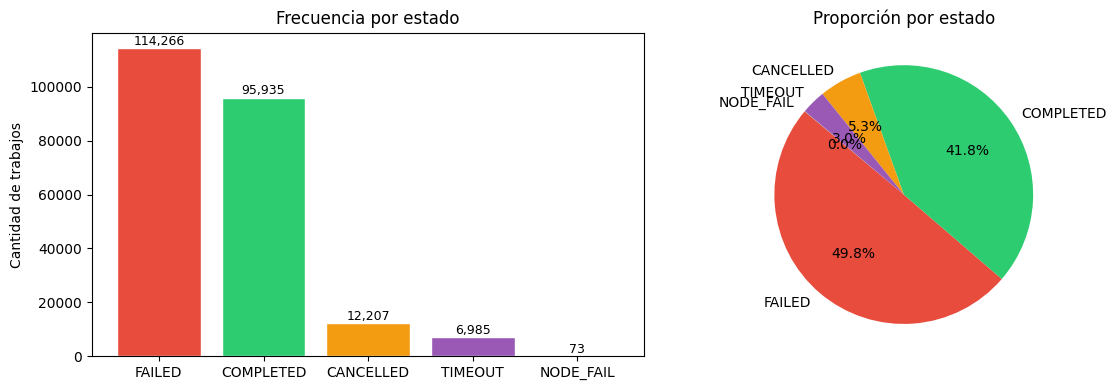


Tabla resumen:


,Trabajos,%
State,,
FAILED,114266,49.80
COMPLETED,95935,41.81
CANCELLED,12207,5.32
TIMEOUT,6985,3.04
NODE_FAIL,73,0.03


In [140]:
df['State'] = df['State'].str.split().str[0]  # Solo la primera palabra (ej. "COMPLETED" de "COMPLETED (0)")
state_counts = df['State'].value_counts()
state_pct = state_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = {'COMPLETED': '#2ecc71', 'FAILED': '#e74c3c', 'CANCELLED': '#f39c12', 'TIMEOUT': '#9b59b6'}
bar_colors = [colors.get(s, '#95a5a6') for s in state_counts.index]
axes[0].bar(state_counts.index, state_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Frecuencia por estado')
axes[0].set_ylabel('Cantidad de trabajos')
for bar, val in zip(axes[0].patches, state_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(state_pct.values, labels=state_pct.index,
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[1].set_title('Proporción por estado')

plt.tight_layout()
plt.show()

print("\nTabla resumen:")
display(pd.DataFrame({'Trabajos': state_counts, '%': state_pct.round(2)}))

### Variable categóricas: `Partition` y `QOS`

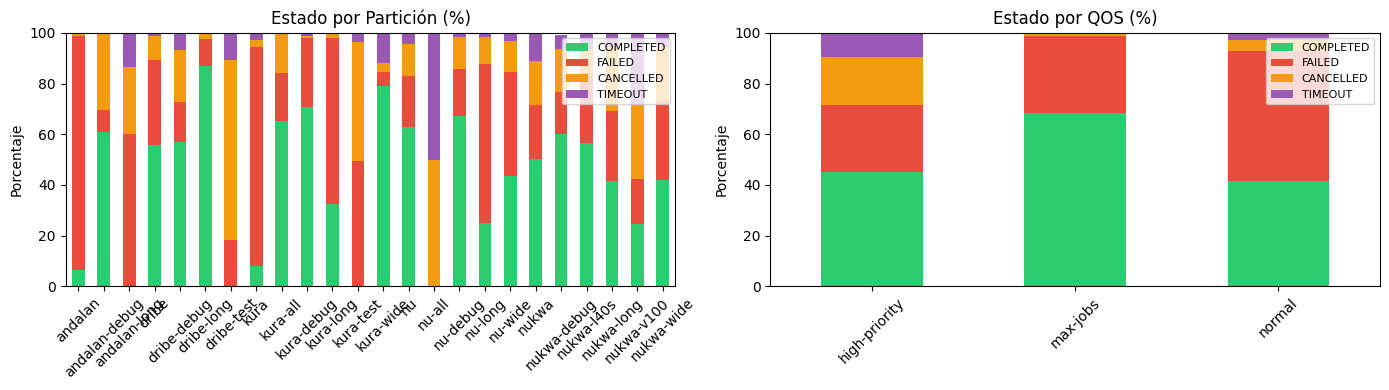

Trabajos por Partición:


,Trabajos
Partition,
kura,71755
dribe-long,39971
dribe,22114
kura-long,17661
andalan,16764
kura-wide,16236
nukwa-l40s,11690
nukwa,6643
nukwa-long,5940



Trabajos por QOS:


,Trabajos
QOS,
normal,214466
high-priority,12815
max-jobs,2185


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Partición
part_state = df.groupby(['Partition', 'State']).size().unstack(fill_value=0)
part_state_pct = part_state.div(part_state.sum(axis=1), axis=0) * 100
part_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0].set_title('Estado por Partición (%)')
axes[0].set_ylabel('Porcentaje')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# QOS
qos_state = df.groupby(['QOS', 'State']).size().unstack(fill_value=0)
qos_state_pct = qos_state.div(qos_state.sum(axis=1), axis=0) * 100
qos_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Estado por QOS (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Trabajos por Partición:")
display(df['Partition'].value_counts().to_frame('Trabajos'))
print("\nTrabajos por QOS:")
display(df['QOS'].value_counts().to_frame('Trabajos'))

Variables numéricas: Distribuciones y outliers

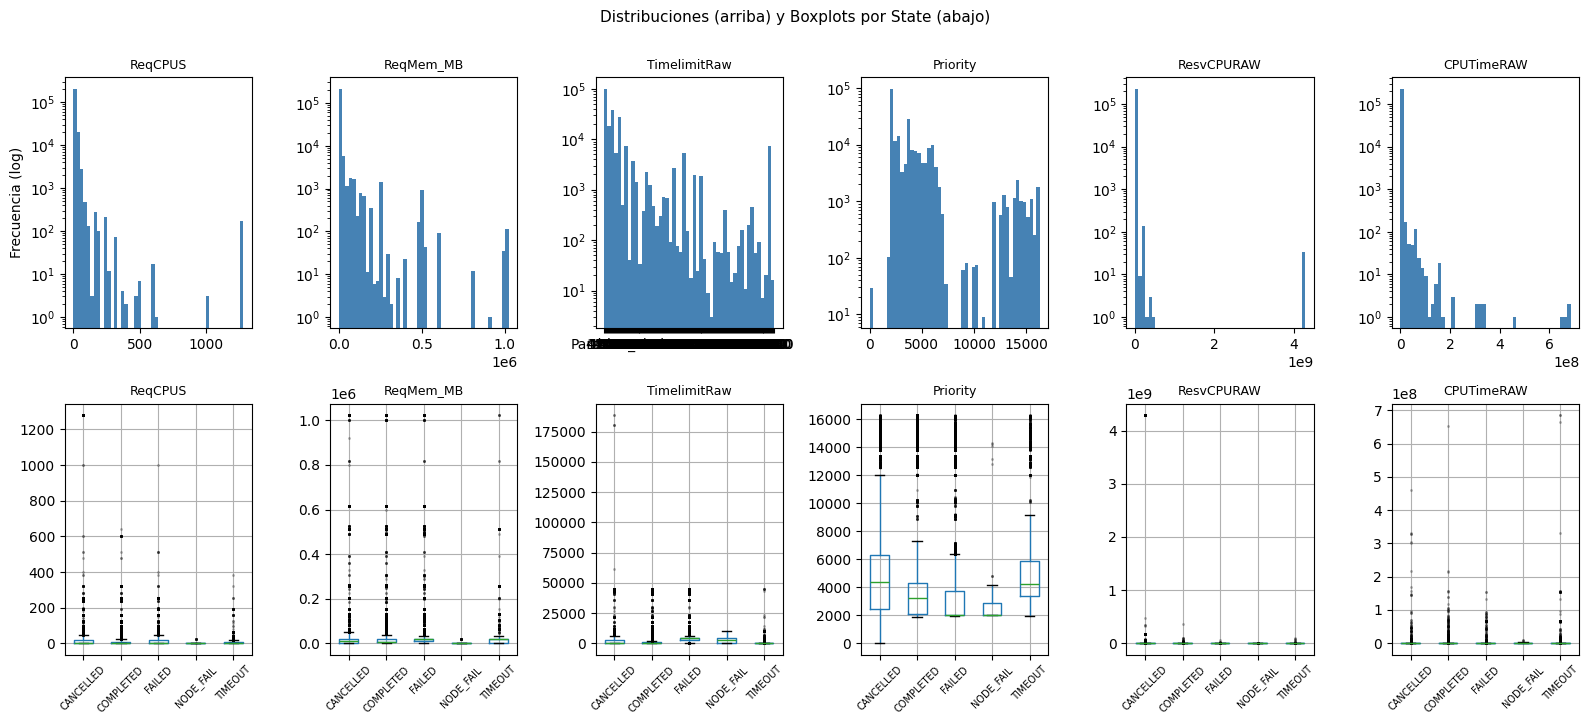

In [142]:
# Parsear ReqMem: convierte '100Mc' -> 100 MB/core, '4Gn' -> 4096 MB/nodo, etc.
def parse_reqmem(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.endswith('Mc'):
        return float(val[:-2])          # MB por core
    elif val.endswith('Mn'):
        return float(val[:-2])          # MB por nodo
    elif val.endswith('Gc'):
        return float(val[:-2]) * 1024   # GB por core -> MB
    elif val.endswith('Gn'):
        return float(val[:-2]) * 1024   # GB por nodo -> MB
    else:
        try:
            return float(val)
        except:
            return np.nan

df['ReqMem_MB'] = df['ReqMem'].apply(parse_reqmem)

num_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitRaw', 'Priority', 'ResvCPURAW', 'CPUTimeRAW']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 7))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histograma (log scale)
    axes[0, i].hist(data, bins=50, color='steelblue', edgecolor='none', log=True)
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Frecuencia (log)' if i == 0 else '')

    # Boxplot por estado
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    plot_df = df.loc[numeric_col.notna(), ['State']].copy()
    plot_df[col] = numeric_col[numeric_col.notna()]
    plot_df.boxplot(column=col, by='State', ax=axes[1, i],
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].set_xlabel('')
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('')
fig.text(0.5, 1.01, 'Distribuciones (arriba) y Boxplots por State (abajo)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### Análisis temporal: Envíos por mes y hora del día

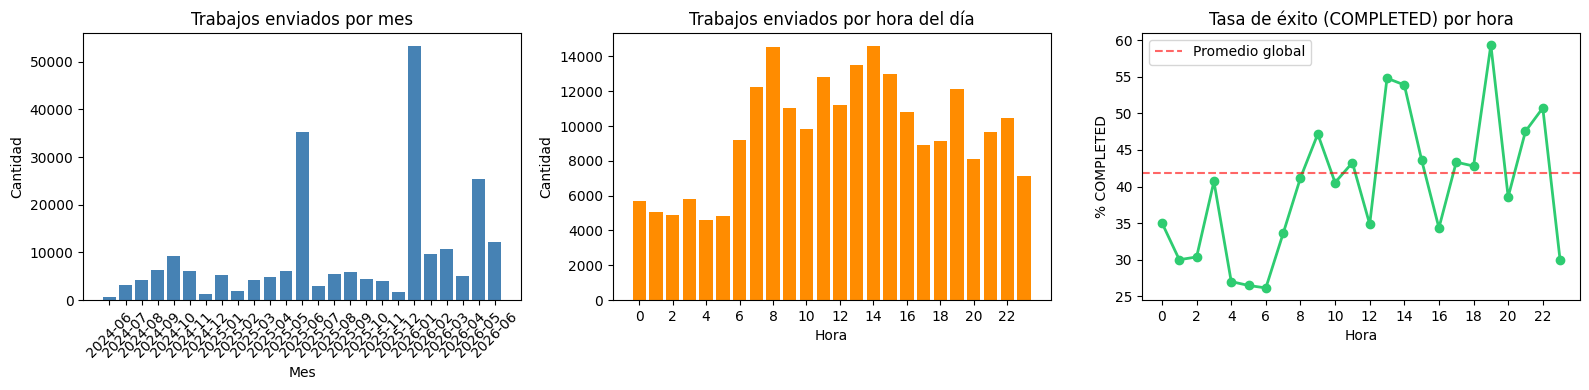

In [143]:
df['submit_month'] = df['Submit'].dt.to_period('M')
df['submit_hour'] = df['Submit'].dt.hour
df['submit_dow'] = df['Submit'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trabajos por mes
month_counts = df.groupby('submit_month').size()
axes[0].bar(month_counts.index.astype(str), month_counts.values, color='steelblue')
axes[0].set_title('Trabajos enviados por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Trabajos por hora del día
hour_counts = df.groupby('submit_hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='darkorange')
axes[1].set_title('Trabajos enviados por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(range(0, 24, 2))

# Tasa de completado por hora del día
completed_by_hour = df[df['State'] == 'COMPLETED'].groupby('submit_hour').size()
total_by_hour = df.groupby('submit_hour').size()
success_rate = (completed_by_hour / total_by_hour * 100).fillna(0)
axes[2].plot(success_rate.index, success_rate.values, marker='o', color='#2ecc71', linewidth=2)
axes[2].set_title('Tasa de éxito (COMPLETED) por hora')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('% COMPLETED')
axes[2].set_xticks(range(0, 24, 2))
axes[2].axhline(df['State'].eq('COMPLETED').mean() * 100, color='red',
                linestyle='--', alpha=0.6, label='Promedio global')
axes[2].legend()

plt.tight_layout()
plt.show()

## Preparación de los datos

### Limpieza de datos (Nulos y duplicados)

In [144]:
# Remover nulos y duplicados
print(f"Shape original: {df.shape}")
print(f"Nulos totales originales: {df.isnull().sum().sum()}")
print(f"Duplicados originales: {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nDespués de limpieza:")
print(f"Shape: {df.shape}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")


Shape original: (229466, 16)
Nulos totales originales: 12516
Duplicados originales: 11258

Después de limpieza:
Shape: (207050, 16)
Nulos totales: 0
Duplicados: 0


### Estandarización de particiones:

In [145]:
df['PartitionGroup'] = df['Partition'].str.split('-').str[0].str.capitalize()  # Unificar por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe)
print("Particiones estandarizadas:")
display(df['PartitionGroup'].value_counts().to_frame('Trabajos'))

Particiones estandarizadas:


,Trabajos
PartitionGroup,
Kura,99602
Dribe,58439
Nukwa,23892
Andalan,16229
Nu,8888


### Manejo de valores no numéricos en `TimelimitRaw`

In [146]:
# Parsear TimelimitRaw según partición:
# - Si es numérico, se conserva.
# - Si viene como "Partition_Limit" (u otro no numérico), se reemplaza por esto:
# nukwa	GPU	1	24 horas
# nukwa-debug	GPU	1	4 horas
# nukwa-wide	GPU	2	24 horas
# nukwa-long	GPU	1	48 horas
# dribe-long	Xeon	1	744 horas
# dribe	Xeon	1	72 horas
# dribe-debug	Xeon	1	8 horas
# kurá-debug	Xeon	1	8 horas
# kurá-wide	Xeon	4	24 horas
# kurá	Xeon	1	72 horas
# kurá-long	Xeon	1	168 horas
# Andalan y Nu igual que Kurá
def parse_timelimit(val, partition):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.isdigit():
        return float(val)
    mapping = {
        'nukwa': 24 * 3600,
        'nukwa-debug': 4 * 3600,
        'nukwa-wide': 24 * 3600,
        'nukwa-long': 48 * 3600,
        'dribe-long': 744 * 3600,
        'dribe': 72 * 3600,
        'dribe-debug': 8 * 3600,
        'kurá-debug': 8 * 3600,
        'kurá-wide': 24 * 3600,
        'kurá': 72 * 3600,
        'kura': 72 * 3600,
        'kurá-long': 168 * 3600,
        'andalan': 72 * 3600,
        'andalan-debug': 8 * 3600,
        'andalan-long': 168 * 3600,
        'nu': 72 * 3600,
        'nu-debug': 8 * 3600,
        'nu-long': 168 * 3600
    }
    for key in mapping:
        if key in partition.lower():
            return mapping[key]
    return np.nan

df['TimelimitSec'] = df.apply(lambda row: parse_timelimit(row['TimelimitRaw'], row['Partition']), axis=1)
print("TimelimitRaw parseado:")
display(df[['TimelimitRaw', 'Partition', 'TimelimitSec']].head(10))

TimelimitRaw parseado:


,TimelimitRaw,Partition,TimelimitSec
0,1440,nukwa-wide,1440.0
1,1440,nukwa-wide,1440.0
2,1440,nukwa-wide,1440.0
3,1440,nukwa-wide,1440.0
4,1440,nukwa-wide,1440.0
5,4200,andalan,4200.0
6,4200,andalan,4200.0
7,1440,kura,1440.0
8,44640,dribe-long,44640.0
9,1440,kura,1440.0


### Correlaciones entre variables numéricas

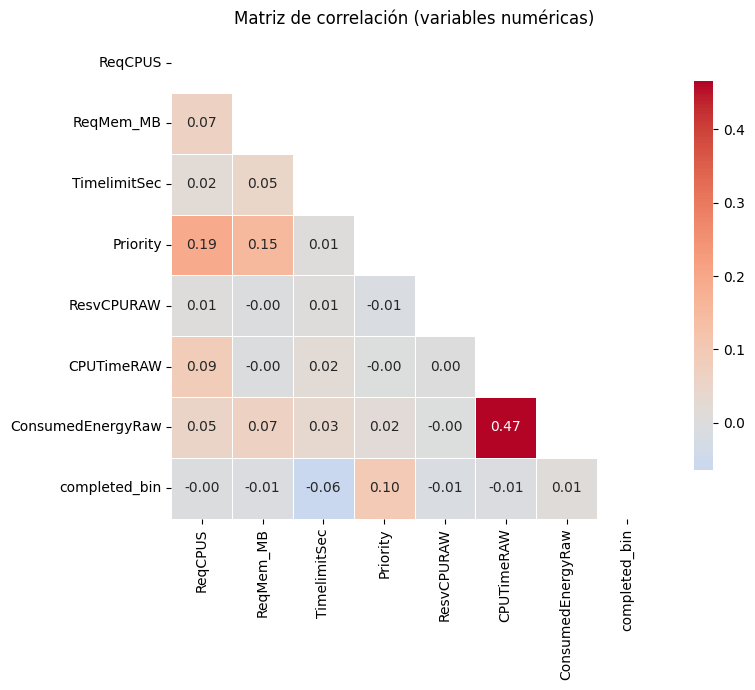


Correlación con 'completed_bin':


Priority             0.096691
TimelimitSec        -0.064057
ResvCPURAW          -0.011195
CPUTimeRAW          -0.009893
ReqMem_MB           -0.008687
ConsumedEnergyRaw    0.008662
ReqCPUS             -0.002794
Name: completed_bin, dtype: float64

In [147]:
# Variable objetivo binaria para correlación
df['completed_bin'] = (df['State'] == 'COMPLETED').astype(int)

corr_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority',
             'ResvCPURAW', 'CPUTimeRAW', 'ConsumedEnergyRaw', 'completed_bin']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print("\nCorrelación con 'completed_bin':")
display(corr_matrix['completed_bin'].drop('completed_bin').sort_values(key=abs, ascending=False))

### Análisis de outliers con IQR

In [148]:
outlier_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority', 'CPUTimeRAW']

rows = []
for col in outlier_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    lb = max(lb, 0)  # No permitir límites negativos
    n_out = ((data < lb) | (data > ub)).sum()
    rows.append({'Columna': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                 'Límite inferior': lb, 'Límite superior': ub,
                 'Outliers': n_out, '% Outliers': round(n_out / len(data) * 100, 2)})

outlier_df = pd.DataFrame(rows).set_index('Columna')
display(outlier_df)

plt.tight_layout()
plt.show()

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
Columna,,,,,,,
ReqCPUS,1.0,10.0,9.0,0,23.5,31485,15.21
ReqMem_MB,2000.0,20000.0,18000.0,0,47000.0,8128,3.93
TimelimitSec,240.0,4200.0,3960.0,0,10140.0,5757,2.78
Priority,1994.0,4290.0,2296.0,0,7734.0,10531,5.09
CPUTimeRAW,20.0,2124.0,2104.0,0,5280.0,39941,19.29


<Figure size 640x480 with 0 Axes>

### One-hot encoding de las variables categóricas

In [149]:
def one_hot(value: str, categories: list[str]) -> list[float]:
    return [1.0 if value.strip() == c else 0.0 for c in categories]

## Creación de matrices de características (X) y etiquetas (y)

En la siguiente celda se muestra la creación de las matrices de características (X) y etiquetas (y) a partir del dataset limpio. La matriz `X` contiene las features numéricas y las variables categóricas codificadas, mientras que la matriz `y` contiene la variable objetivo binaria que indica si el trabajo fue completado exitosamente o no. Esto es fundamental para el entrenamiento del modelo kNN, que requiere una representación numérica de los datos. Los datos categóricos se codifican utilizando one-hot encoding, lo que permite al modelo interpretar cada categoría como una dimensión separada en el espacio de características.

In [150]:
PARTITION_GROUPS = df['PartitionGroup'].unique().tolist()
QOS_CATEGORIES = df['QOS'].unique().tolist()

def build_features(row: dict) -> list[float] | None:
    """
    Returns a feature vector or None if the row has critical missing values.

    Feature vector layout (14 dims):
      [0]  ReqCPUS
      [1]  ReqMem_MB
      [2]  ReqNodes
      [3]  ResvCPURAW
      [4]  TimelimitSec
      [5]  Priority
      [6]  submit_hour
      [7]  submit_dow
      [8..12]  one-hot Partition  (5 categories)
      [13,14]  one-hot QOS        (2 categories)
    """
    try:
        req_cpus = float(row["ReqCPUS"])
        req_mem = float(row["ReqMem_MB"])
        req_nodes = float(row["ReqNodes"])
        resv_cpu = float(row["ResvCPURAW"])
        timelimit = float(row["TimelimitSec"])
        priority = float(row["Priority"])
        hour, dow = float(row["submit_hour"]), float(row["Submit"].dayofweek)
    except (ValueError, KeyError):
        print(f"Fila con datos faltantes o no numéricos: {row.get('JobID', 'N/A')}")
        return None

    vec = [
        req_cpus,
        req_mem,
        req_nodes,
        resv_cpu,
        timelimit,
        priority,
        float(hour),
        float(dow),
        *one_hot(row["PartitionGroup"], PARTITION_GROUPS),
        *one_hot(row["QOS"], QOS_CATEGORIES),
    ]
    return vec

In [151]:
### Modificado del notebook original por issue de indexing
X_raw, y_raw = [], []

for _, row in df.iterrows():
    features = build_features(row)
    if features is not None:
        X_raw.append(features)
        # Build y in the same loop, only for rows that produced valid features
        y_raw.append(1 if row['State'].strip() == 'COMPLETED' else 0)

# Convert to numpy arrays
X_raw = np.array(X_raw, dtype=np.float32)
y_raw = np.array(y_raw, dtype=np.float32)

print(f"X shape: {X_raw.shape}, y shape: {y_raw.shape}")

X shape: (207050, 16), y shape: (207050,)


### División del dataset

Como para este proyecto lo importante era la implementación del algoritmo de MLP sin uso de librería, vamos a utilizar sklearn para la división y normalización del dataset

In [152]:
# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size = 0.2, random_state = 42, stratify = y_raw
)

### Normalizacion de datos

In [153]:
# Instanciamos el scaler
scaler = MinMaxScaler()

# Entrenamos el scaler con los datos de entrenamiento únicamente para evitar data leakage
X_train = scaler.fit_transform(X_train)

# Ahora transformamos el set de entrenamiento
X_test = scaler.transform(X_test)

### Fit y predict del modelo

In [ ]:
# Obtenemos el número de features para la capa de entrada
number_of_features = X_train.shape[1]

# Instanciamos el modelo
model = MLP(layer_sizes=[number_of_features, 64, 32, 1], seed=42)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    lr=0.001,
    verbose=True,
)

Epoch    1/50 - loss: 0.4175 - train_acc: 0.8241
Epoch    5/50 - loss: 0.3242 - train_acc: 0.8381
Epoch   10/50 - loss: 0.3012 - train_acc: 0.8447
Epoch   15/50 - loss: 0.2914 - train_acc: 0.8488
Epoch   20/50 - loss: 0.2846 - train_acc: 0.8542
Epoch   25/50 - loss: 0.2792 - train_acc: 0.8592
Epoch   30/50 - loss: 0.2757 - train_acc: 0.8587
Epoch   35/50 - loss: 0.2730 - train_acc: 0.8598
Epoch   40/50 - loss: 0.2706 - train_acc: 0.8618
Epoch   45/50 - loss: 0.2689 - train_acc: 0.8593
Epoch   50/50 - loss: 0.2674 - train_acc: 0.8615


## Evaluación

### Análisis y visualización de resultados

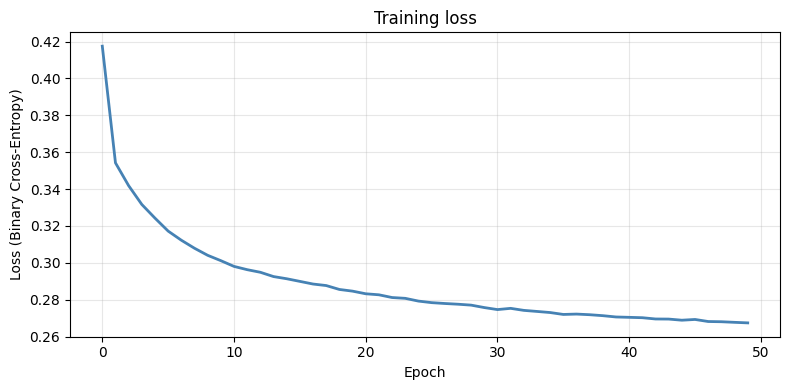

In [ ]:
# Binary Cross Entropy Loss
plt.figure(figsize=(8, 4))
plt.plot(history, color = "steelblue", linewidth = 2)
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("Training loss")
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [156]:

# Predicted probabilities (continuous, between 0 and 1)
y_proba = model.predict_proba(X_test).ravel()

# Hard predictions at the default 0.5 threshold
y_pred = (y_proba >= 0.5).astype(int)

# Make sure y_test is a numpy array (it should be after the fix from the previous step)
y_test = np.asarray(y_test)

print(f"Predicciones generadas: {len(y_pred)}")
print(f"Distribución de predicciones: {np.bincount(y_pred)}")
print(f"Distribución real:           {np.bincount(y_test.astype(int))}")

Predicciones generadas: 41410
Distribución de predicciones: [18730 22680]
Distribución real:           [22389 19021]


### Métricas de rendimiento

In [157]:
print("=" * 50)
print("Métricas en el conjunto de test")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")

Métricas en el conjunto de test
Accuracy:  0.8606
Precision: 0.7921
Recall:    0.9445
F1-score:  0.8616
ROC AUC:   0.9487


### Matriz de confusión



Matriz de confusión:
[[17674  4715]
 [ 1056 17965]]


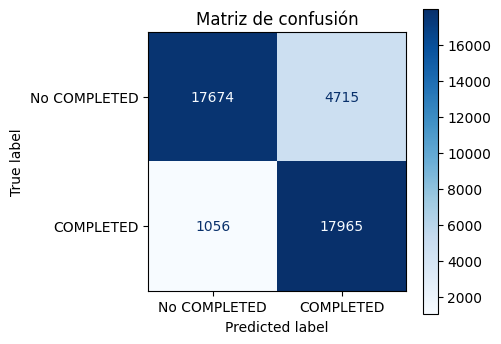

In [158]:
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    cm,
    display_labels=["No COMPLETED", "COMPLETED"]
).plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

### Reporte de clasificación

In [159]:
print("\nReporte de clasificación:")
print(classification_report(
    y_test, y_pred,
    target_names=["No COMPLETED", "COMPLETED"],
    digits=4
))


Reporte de clasificación:
              precision    recall  f1-score   support

No COMPLETED     0.9436    0.7894    0.8597     22389
   COMPLETED     0.7921    0.9445    0.8616     19021

    accuracy                         0.8606     41410
   macro avg     0.8679    0.8669    0.8606     41410
weighted avg     0.8740    0.8606    0.8606     41410



### ROC y Curva Precision-Recall

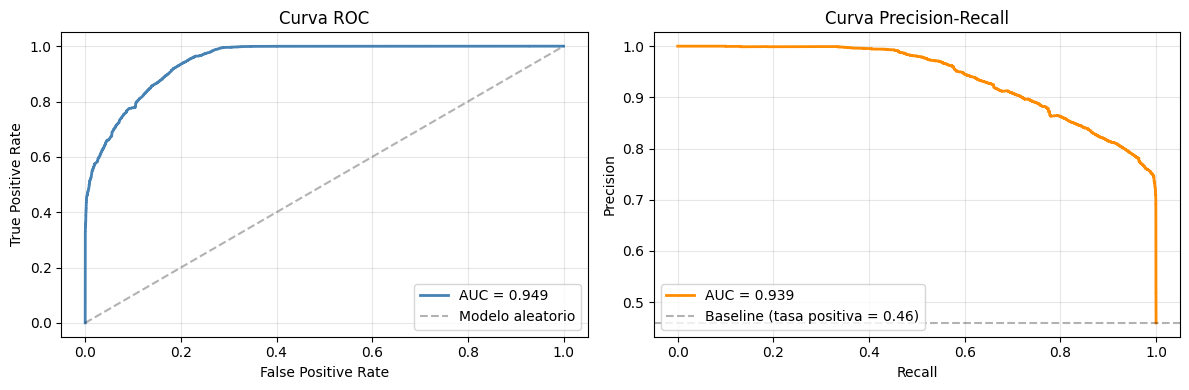

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Modelo aleatorio")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)
axes[1].plot(recall_vals, precision_vals, color="darkorange", linewidth=2,
             label=f"AUC = {pr_auc:.3f}")
# Línea de referencia: tasa base de clase positiva
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.3,
                label=f"Baseline (tasa positiva = {baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación con baseline (proyecto anterior)

In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Baseline 1: always predict the majority class
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)

# Baseline 2: logistic regression (simple linear model)
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)

print("Comparación de modelos:")
print(f"  Dummy (mayoría):     accuracy = {dummy_acc:.4f}")
print(f"  Regresión logística: accuracy = {accuracy_score(y_test, lr_pred):.4f}, "
      f"AUC = {roc_auc_score(y_test, lr_proba):.4f}")
print(f"  MLP (tu modelo):     accuracy = {accuracy_score(y_test, y_pred):.4f}, "
      f"AUC = {roc_auc_score(y_test, y_proba):.4f}")

Comparación de modelos:
  Dummy (mayoría):     accuracy = 0.5407
  Regresión logística: accuracy = 0.7487, AUC = 0.8443
  MLP (tu modelo):     accuracy = 0.8606, AUC = 0.9487
